In [44]:
import nltk
import numpy as np
import networkx as nx
import pandas as pd
from nltk.tokenize import sent_tokenize, word_tokenize
import re
from collections import Counter
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer

# First, I will download the Punkt tokeniser models for sentence splitting and work tokenisation
nltk.download('punkt')
# Then, I will download the part-of-speech (POS) tagging model which is necessary for identifying noun phrases in the text
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

df = pd.read_pickle(r"data_preprocessed.pkl")
print("Number of rows:", df.shape[0])
print("Columns:", df.columns.tolist())
text_column='abstract'
# Using regex for valid words
Valid_word=re.compile(r'^[a-zA-Z\-]+$')

Number of rows: 27121
Columns: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'abstract', 'report-no', 'categories', 'versions', 'year', 'cleaned_abstract', 'period']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\clare\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\clare\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\clare\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\clare\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [45]:
# This function will calculate universal IDF to measure word importance for all of the abstracts
def calculate_universal_IDF(preprocessed_tokens_list):
    N=len(preprocessed_tokens_list)
    document_frequency=Counter()
    for tokens in tqdm(preprocessed_tokens_list, desc="IDF Progress"):
        unique_words=set(tokens)
        document_frequency.update(unique_words)
    idf={w: np.log(N / (1 + f)) for w, f in document_frequency.items()}
    return idf
preprocessed_tokens_list=[str(text).split() for text in df[text_column].tolist()]
universal_IDF=calculate_universal_IDF(preprocessed_tokens_list)

# By this, I will convert a sentence into a numerical vector using TF-IDF
def sentence_vector(tokens, vocabulary, universal_IDF):
    if not tokens:
        return np.zeros(len(vocabulary))
    vector=np.zeros(len(vocabulary))
    Term_frequency=Counter(tokens)
    for word, count in Term_frequency.items():
        if word in vocabulary:
            vector[vocabulary[word]]=(count / len(tokens)) * universal_IDF.get(word, 1.0)
    return vector

IDF Progress: 100%|██████████| 27121/27121 [00:00<00:00, 29627.58it/s]


In [46]:
# This function converts text into sentences and a numerical vocabulary so that TextRank can calculate sentence importance
def textrank_summarise(preprocessed_text, top_n=3, position_bias=0.3):
    if not isinstance(preprocessed_text, str):
        return preprocessed_text
    sentences=sent_tokenize(preprocessed_text)
    if len(sentences) <= top_n:
        return preprocessed_text
    all_words=set(preprocessed_text.split())
    vocabulary={w: i for i, w in enumerate(all_words)}

    # Now, I will convert all sentences into normalised numerical vectors so they can be fairly based on their similarities
    vectors=np.array([sentence_vector(sent.split(), vocabulary, universal_IDF) for sent in sentences])
    norm=np.linalg.norm(vectors, axis=1, keepdims=True)
    norm[norm == 0] = 1e-10
    vectors=vectors / norm
    
    # Then here, I am computing cosine similarity between all pairs of sentences
    similarity_matrix=np.clip(vectors @ vectors.T, 0, None)
    np.fill_diagonal(similarity_matrix, 0)
    # Converting the similarity matrix into a graph using NetworkX
    Graph_sentences=nx.from_numpy_array(similarity_matrix)
    # Then, I will apply PageRank algorithm to the graph
    scores=nx.pagerank(Graph_sentences, max_iter=200, tol=1e-6)

    position_raw=np.exp(-0.5 * np.arange(len(sentences)))
    # Normalising the raw position scores so they sum to 1
    position_score=position_raw / position_raw.sum()
    final_scores={i: (1 - position_bias) * scores[i] + position_bias * position_score[i] for i in range(len(sentences))}
    # Here, I will pick the top important sentences based on the combined score
    ranked_index_row=sorted(final_scores, key=final_scores.get, reverse=True)[:top_n]

    return ' '.join(sentences[i] for i in sorted(ranked_index_row))

# I am using Penn Treebank tags to define the structure of a Noun phrase
Noun_Phrase_Grammar=r'KP: {(<JJ.*>|<NN.*>)*<NN.*>}'
Noun_Phrase_Parser=nltk.RegexpParser(Noun_Phrase_Grammar)

In [47]:
# This function will extract noun phrases from the text using the defined grammar and filter them based on length and valid characters
def extract_noun_phrases(text):
    tokens=word_tokenize(text)
    tagged=nltk.pos_tag(tokens)
    tree=Noun_Phrase_Parser.parse(tagged)
    phrases = []
    
    for subtree in tree.subtrees(filter=lambda t: t.label() == 'KP'):
        words = [w.lower() for w, _ in subtree.leaves()]
        valid_words = [w for w in words if Valid_word.match(w)]
        # filtering out phrases on the basis of length and valid characters
        if 1 <= len(valid_words) <= 5:
            phrase=' '.join(valid_words)
            phrases.append(phrase)
    return phrases

# I will use this function to remove redundant keyphrases that are substrings of each other
def filter_redundant_phrases(ranked_phrases, top_n):
    filtered=[]
    for phrase in ranked_phrases:
        if not any(phrase in f or f in phrase for f in filtered):
            filtered.append(phrase)
        if len(filtered) >= top_n:
            break
    return filtered

In [48]:
# Finally, I have made this function, which will extract and rank important keyphrases using TextRank graph
def textrank_keyphrases(text, top_n=10, window=5):
    if not isinstance(text, str):
        return []
    phrases=extract_noun_phrases(text)
    if len(phrases) < 3:
        return phrases[:top_n]
    unique_phrases=list(dict.fromkeys(phrases))
    Graph_sentences=nx.Graph()
    Graph_sentences.add_nodes_from(unique_phrases)
    for i, p in enumerate(phrases):
        for q in phrases[i+1:i+window]:
            if p != q:
                if Graph_sentences.has_edge(p, q):
                    Graph_sentences[p][q]['weight'] += 1
                else:
                    Graph_sentences.add_edge(p, q, weight=1)

    # Applying the PageRank
    PageRank=nx.pagerank(Graph_sentences, weight='weight', max_iter=200, tol=1e-6)
    
    # It is the final scoring function
    def final_score(phrase):
        return PageRank.get(phrase, 0) * (1 + 0.15 * (len(phrase.split()) - 1))
    ranked=sorted(unique_phrases, key=final_score, reverse=True)

    return filter_redundant_phrases(ranked, top_n)

print("\nRunning TextRank summarisation and keyphrase extraction in parallel")

def process_summaries(texts):
    return [textrank_summarise(t) for t in texts]

def process_keyphrases(texts):
    return [textrank_keyphrases(t) for t in texts]

# Splitting the data into chunks for parallel processing
n_cores=joblib.cpu_count()
text_chunks=np.array_split(df[text_column].astype(str), n_cores)

# Running the parallel summarisation
df['summary']=sum( joblib.Parallel(n_jobs=n_cores)( joblib.delayed(process_summaries)(chunk) for chunk in tqdm(text_chunks, desc="Summarising") ), [] )

# Running the parallel keyphrase extraction
df['keyphrases']=sum( joblib.Parallel(n_jobs=n_cores)( joblib.delayed(process_keyphrases)(chunk) for chunk in tqdm(text_chunks, desc="Extracting Keyphrases") ), [] )

pd.set_option('display.max_colwidth', 120)
print("First 3 rows")
for index_row, row in df[[text_column,'year','summary','keyphrases']].head(3).iterrows():
    print(f"\n[Row {index_row}]")
    print(f"Year: {row['year']}")
    print(f"Summary: {str(row['summary'])[:200]}")
    print(f"Keyphrases: {', '.join(row['keyphrases'])}")
df.to_pickle("data_with_nlp.pkl")
df[[text_column, 'year', 'summary', 'keyphrases']].to_csv("nlp_results.csv", index=False)
print("\nSaved data_with_nlp.pkl and nlp_results.csv")


Running TextRank summarisation and keyphrase extraction in parallel


C:\Users\clare\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
Extracting Keyphrases: 100%|██████████| 8/8 [00:00<00:00, 6680.16it/s]


First 3 rows

[Row 0]
Year: 2007
Summary:   This paper uncovers and explores the close relationship between Monte Carlo
Optimization of a parametrized integral (MCO), Parametric machine-Learning
(PL), and `blackbox' or `oracle'-based optimiza
Keyphrases: mco, pl techniques, bo, integrand, immediate sampling, contributions, values, new application domain, sample point locations, sample location information

[Row 1]
Year: 2007
Summary:   In these notes we formally describe the functionality of Calculating Valid
Domains from the BDD representing the solution space of valid configurations.
The formalization is largely based on the CLa
Keyphrases: solution space, calculating valid domains, bdd, valid configurations, clab configuration framework, functionality, formalization, notes

[Row 2]
Year: 2007
Summary:   Motivation: Profile hidden Markov Models (pHMMs) are a popular and very
useful tool in the detection of the remote homologue protein families. We present HMMER-STRUCT, a model constr

In [49]:
# Loading the data from pickle file
lemmatizer=WordNetLemmatizer()
df=pd.read_pickle("data_with_nlp.pkl")

bins=[2007, 2012, 2017, 2022]
labels=["2007–2011", "2012–2016", "2017–2021"]
df['year_bin']=pd.cut(df['year'], bins=bins, labels=labels, right=False)

# This function removes plural "s" if it's a simple word ending in s
def clean_phrase(text):
    tokens=text.split()
    lemmas=[lemmatizer.lemmatize(t) for t in tokens]
    cleaned=[]
    for t in lemmas:
        if len(t) > 3 and t.endswith("s") and not t.endswith("ss"):
            t=t[:-1]
        cleaned.append(t)
    return " ".join(cleaned)

# Here, I keep phrases that actually represent meaningful AI methods
AI_methods=["support vector machine", "svm", "convolutional neural network", "cnn", "recurrent neural network", "rnn", "transformer", "bert", "self attention", "attention mechanism", "reinforcement learning", "backpropagation", "stochastic gradient descent", "gradient descent", "deep learning" ]

# Here, I filter out generic terms
Generic_terms=set(["feature", "features", "accuracy", "prediction", "loss", "classification", "regression", "network", "neural", "nlp", "vision", "learning", "model", "models", "training", "dataset", "datasets", "machine", "optimization", "gradient", "clustering"])

df_exploded=df[['year_bin', 'keyphrases']].explode('keyphrases')
df_exploded=df_exploded.dropna()
df_exploded['keyphrases']=df_exploded['keyphrases'].apply(clean_phrase)

C:\Users\clare\AppData\Local\Temp\ipykernel_24740\1027710762.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  growth_score= (df_exploded.groupby('year_bin').size().reset_index(name='ai_ml_research_activity_score'))
C:\Users\clare\AppData\Local\Temp\ipykernel_24740\1027710762.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend=(df_exploded.groupby(['year_bin', 'keyphrases']) .size() .reset_index(name='count').sort_values(['year_bin','count'], ascending=[True, False]) )
C:\Users\clare\AppData\Local\Temp\ipykernel_24740\1027710762.py:18: FutureWarning: The default of observed=False is deprecated and w


 AI/ML Research Activity Score
    year_bin  ai_ml_research_activity_score
0  2007–2011                             31
1  2012–2016                            171
2  2017–2021                           1667

AI/ML related terms per Era
 year_bin                          keyphrases  count
2007–2011                                 svm      6
2007–2011    reproducing kernel hilbert space      4
2007–2011                       hilbert space      2
2007–2011                      svm classifier      2
2007–2011                               c-svm      1
2007–2011                   decomposition svm      1
2007–2011               general hilbert space      1
2007–2011                  general scaled svm      1
2007–2011                              gs-svm      1
2007–2011 hard margin pattern recognition svm      1
2012–2016                                 svm     19
2012–2016                                 rnn     18
2012–2016                 attention mechanism     13
2012–2016            

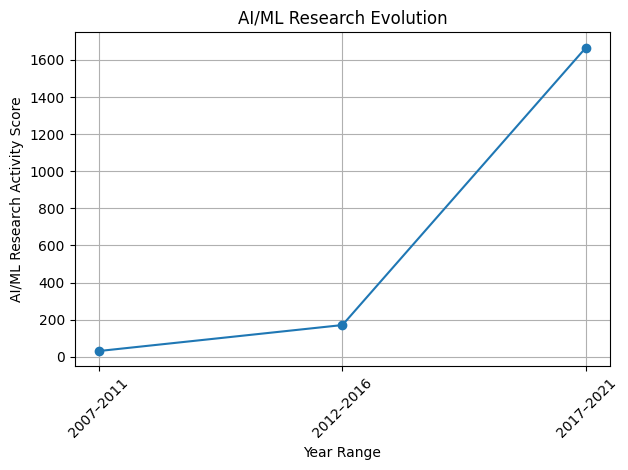

In [50]:
# This function checks if a keyphrase is relevant to AIML
def valid_ai_ml(text):
    text=str(text)
    signal_keyword=any(phrase in text for phrase in AI_methods)
    # rejecting if it contains generic words
    tokens=set(text.split())
    noise=any(term in tokens for term in Generic_terms)

    return signal_keyword and not noise
df_exploded=df_exploded[df_exploded['keyphrases'].apply(valid_ai_ml)]

growth_score= (df_exploded.groupby('year_bin').size().reset_index(name='ai_ml_research_activity_score'))
print("\n AI/ML Research Activity Score")
print(growth_score)

# These are the top Keyphrases per era
trend=(df_exploded.groupby(['year_bin', 'keyphrases']) .size() .reset_index(name='count').sort_values(['year_bin','count'], ascending=[True, False]) )
top_trends=trend.groupby('year_bin').head(10)
print("\nAI/ML related terms per Era")
print(top_trends.to_string(index=False))
# save CSV
top_trends.to_csv("ai_ml_terms_per_era.csv", index=False)

plt.figure()
plt.plot(growth_score['year_bin'].astype(str),growth_score['ai_ml_research_activity_score'],marker='o')
plt.xlabel("Year Range")
plt.ylabel("AI/ML Research Activity Score")
plt.title("AI/ML Research Evolution")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("ai_ml_research_evolution.png", dpi=300, bbox_inches='tight')
plt.show()


In [42]:
Noise_words = set([ "set", "number", "case", "order", "new", "information", "result", "results", "method", "methods", "approach", "approaches", "study", "paper", "work", "analysis", "data", "dataset", "datasets", "model", "models", "word", "words", "rule", "rules", "agent", "agents", "system", "systems", "task", "tasks", "problem", "problems", "experimental", "previous", "based", "using", "use", "used", "probability", "uncertainty", "language", "training", "algorithm", "performance", "term", "experiment", "technique", "framework", "feature", "sentence", "text", "question", "user", "domain", "knowledge", "constraint", "ontology", "network", "sequence", "semantics", "classification", "accuracy", "example", "plan", "property", "application", "class", "complexity", "variable", "context", "expert", "representation", "concept", "time", "inference", "theory", "entity", "corpus", "english" ])

Bad_phrases = set(["state-of-the-art", "previous work", "this paper", "this study", "experimental result", "experimental results", "classification accuracy" ])

Keep_phrases = set([ "support vector machine", "bayesian network", "belief network", "natural language processing", "artificial intelligence", "machine learning", "deep learning", "neural network", "artificial neural network", "recurrent neural network", "deep neural network", "convolutional neural network", "neural machine translation", "machine translation", "word embedding", "word embeddings", "semantic web", "stable model semantics", "bert", "transformer", "named entity recognition", "sentiment analysis", "question answering", "speech recognition", "text summarization" ])

#Used for strict relevance filtering
Core_terms = [ "support vector", "bayesian", "belief network", "neural", "bert", "transformer", "embedding", "translation", "machine learning", "deep learning", "artificial intelligence", "natural language processing", "named entity", "sentiment", "question answering", "speech recognition", "summarization", "semantic web" ]

#Clean phrases
def clean_phrase(text):
    if pd.isna(text):
        return None
    text = str(text).lower().strip()
    text = re.sub(r"[^a-zA-Z\s\-]", "", text)
    if text == "":
        return None
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = [t for t in tokens if len(t) > 2]
    if not tokens:
        return None
    phrase = " ".join(tokens)
    if phrase in Bad_phrases:
        return None
    #keep important phrases
    if phrase in Keep_phrases:
        return phrase
    #remove single generic words
    if len(tokens) == 1 and tokens[0] in Noise_words:
        return None
    #remove phrases fully made of generic words
    if all(t in Noise_words for t in tokens):
        return None

    #remove generic phrases directly
    Remove_phrases = set([ "network", "sequence", "semantics", "classification", "classification accuracy", "representation", "concept", "context", "application", "entity", "corpus", "english", "time", "theory", "inference", "example", "plan", "property", "class", "complexity", "variable", "expert" ])
    if phrase in Remove_phrases:
        return None

    #remove phrases ending in generic heads
    Generic_heads = set([ "algorithm", "performance", "term", "experiment", "technique", "framework", "feature", "sentence", "text", "question", "user", "domain", "knowledge", "constraint", "ontology", "network", "sequence", "semantics", "classification", "accuracy", "representation", "concept", "application", "context", "entity", "corpus", "theory", "time", "property", "variable", "class", "example", "plan", "expert" ])

    if tokens[-1] in Generic_heads:
        return None

    #strict relevance filter:
    #only keep phrases that contain meaningful AI/ML/NLP signal
    if not any(term in phrase for term in Core_terms):
        return None

    return phrase

#Explode keyphrases
df_exploded = df[["period", "keyphrases"]].explode("keyphrases")
df_exploded = df_exploded.dropna(subset=["period", "keyphrases"])

#Clean keywords
df_exploded["keyword"] = df_exploded["keyphrases"].apply(clean_phrase)
df_exploded = df_exploded.dropna(subset=["keyword"])

#Count frequency by period
keyword_scores = ( df_exploded .groupby(["period", "keyword"]) .size() .reset_index(name="score") )

#Top 10 per period
top_keywords = ( keyword_scores .sort_values(["period", "score"], ascending=[True, False]) .groupby("period", group_keys=False) .head(10) )

#Show format
top_keywords = top_keywords[["keyword", "score", "period"]]

#Save CSV
top_keywords.to_csv("top_10_keywords.csv", index=False)

#Print output
print("\nTop 10 AI/ML related terms keywords per period:")
print(top_keywords.to_string(index=False))

print("\nSaved as: top_10_keywords.csv")


Top 10 AI/ML related terms keywords per period:
                         keyword  score    period
          support vector machine     14 2007-2011
     natural language processing     12 2007-2011
                machine learning     11 2007-2011
         artificial intelligence     10 2007-2011
                  neural network      8 2007-2011
                    semantic web      8 2007-2011
          stable model semantics      5 2007-2011
       artificial neural network      4 2007-2011
             machine translation      4 2007-2011
reproducing kernel hilbert space      4 2007-2011
                bayesian network     74 2012-2016
     natural language processing     66 2012-2016
         artificial intelligence     63 2012-2016
        recurrent neural network     57 2012-2016
                machine learning     45 2012-2016
                  neural network     43 2012-2016
             deep neural network     39 2012-2016
                  belief network     34 2012-2016
 